# Week 10 Lab: Logistic Regression and Classification Evaluation

<a href="https://colab.research.google.com/github/bradleyboehmke/uc-bana-4080/blob/main/labs/10_wk10_lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Welcome to Week 10! This lab serves as both your Thursday class session and your homework for the week. You'll apply logistic regression and classification evaluation techniques to two important business scenarios: credit risk assessment and medical diagnosis support.

In the business world, classification problems are everywhere—from determining loan approvals to medical screenings. Today you'll master the complete workflow from data preparation through model evaluation, learning to choose appropriate metrics that align with business objectives and costs.

## 🎯 Learning Objectives
By the end of this lab, you will be able to:
- Apply the complete logistic regression workflow: data preparation, model fitting, and interpretation
- Calculate and interpret baseline ratios for imbalanced classification problems
- Evaluate classification models using precision, recall, F1-score, and ROC-AUC metrics
- Select appropriate evaluation metrics based on business context and error costs

## 📚 This Lab Reinforces
- **Chapter 23: Introduction to Logistic Regression for Classification**
- **Chapter 24: Evaluating Classification Models**
- **Tuesday's Lecture: Classification Methods and Model Evaluation**

## 🕐 Estimated Time & Structure
**Total Time:** 75 minutes  
**Mode:** Individual work (this serves as your homework)

- **[0–10 min]** Review: Default dataset logistic regression workflow
- **[10–35 min]** Application: Breast Cancer Wisconsin dataset analysis
- **[35–70 min]** Independent challenges: Specific homework questions
- **[70–75 min]** Wrap-up and submission preparation

## 💡 Why This Matters
Classification problems drive critical business decisions across industries. Credit companies need to assess default risk, healthcare systems require diagnostic support, and marketing teams must identify likely customers. The ability to build, evaluate, and interpret classification models—while understanding the business implications of different types of errors—is essential for data-driven decision making. Today's lab prepares you to tackle these real-world challenges with confidence.

## Setup
We'll work with two datasets: the Default dataset from ISLP (for review) and the Breast Cancer Wisconsin dataset (for our main analysis). Both represent important classification scenarios in business and healthcare.

In [2]:
# Required imports
!pip install ISLP # Install the ISLP package
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve
)
from ISLP import load_data
import warnings
warnings.filterwarnings('ignore')

# Set random state for reproducibility
RANDOM_STATE = 42

print("✅ All libraries imported successfully!")
print("🎯 Ready to dive into classification analysis!")

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 28.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.6/84.6 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 48.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 49.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 7.4 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=8307dcdb7ea090e93f53e57f6e6f0039984ad433e55c3b118344b2802653755e
  Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma
✅ All libraries imported successfully!
🎯 Ready to dive into classification analysis!


## Part 1 — Review: Default Dataset Logistic Regression (10 minutes)

Let's quickly review the complete logistic regression workflow using the Default dataset from Chapters 23-24. This will reinforce the key concepts before we tackle the main dataset.

### Quick Workflow Review

We'll walk through each step systematically:

**📋 Step-by-step process:**
1. Load data and compute baseline ratio
2. Prepare features with dummy encoding
3. Split data into training and test sets
4. Fit logistic regression model and interpret coefficients
5. Make predictions and evaluate using multiple metrics

In [3]:
# Step 1: Load Default dataset and examine baseline
Default = load_data('Default')

print("Default Dataset Overview:")
print(f"Shape: {Default.shape}")
print(f"\nColumns: {Default.columns.tolist()}")
print(f"\nFirst few rows:")
print(Default.head())

# Compute baseline ratio
baseline_default_rate = (Default['default'] == 'Yes').mean()
print(f"\n📊 Baseline Analysis:")
print(f"Default rate: {baseline_default_rate:.1%}")
print(f"Non-default rate: {1-baseline_default_rate:.1%}")

Default Dataset Overview:
Shape: (10000, 4)

Columns: ['default', 'student', 'balance', 'income']

First few rows:
  default student      balance        income
0      No      No   729.526495  44361.625074
1      No     Yes   817.180407  12106.134700
2      No      No  1073.549164  31767.138947
3      No      No   529.250605  35704.493935
4      No      No   785.655883  38463.495879

📊 Baseline Analysis:
Default rate: 3.3%
Non-default rate: 96.7%


In [4]:
# Step 2: Prepare data with dummy encoding
# Convert categorical variables to numeric
Default_encoded = pd.get_dummies(Default, columns=['student'], drop_first=True)
Default_encoded['default_binary'] = (Default_encoded['default'] == 'Yes').astype(int)

# Define features and target
X = Default_encoded[['balance', 'income', 'student_Yes']]
y = Default_encoded['default_binary']

print("Data Preparation Complete:")
print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeature columns: {X.columns.tolist()}")

Data Preparation Complete:
Features shape: (10000, 3)
Target shape: (10000,)

Feature columns: ['balance', 'income', 'student_Yes']


In [5]:
# Step 3: Split data (70-30 split as specified for homework questions)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_STATE
)

print(f"📊 Data Split Results:")
print(f"Training set: {len(X_train):,} observations")
print(f"Test set: {len(X_test):,} observations")
print(f"\nTraining set default rate: {y_train.mean():.1%}")
print(f"Test set default rate: {y_test.mean():.1%}")

📊 Data Split Results:
Training set: 7,000 observations
Test set: 3,000 observations

Training set default rate: 3.4%
Test set default rate: 3.1%


In [6]:
# Step 4: Fit logistic regression model
model = LogisticRegression(random_state=RANDOM_STATE)
model.fit(X_train, y_train)

# Extract and interpret coefficients
print("🔍 Model Coefficients:")
print(f"Intercept: {model.intercept_[0]:.6f}")
for feature, coef in zip(X.columns, model.coef_[0]):
    print(f"{feature}: {coef:.6f}")

print(f"\n💡 Interpretation:")
print(f"• Balance: Positive coefficient means higher balance increases default risk")
print(f"• Income: Very small coefficient suggests minimal impact after accounting for balance")
print(f"• Student: Negative coefficient means students have lower default risk (holding other factors constant)")

🔍 Model Coefficients:
Intercept: -11.108164
balance: 0.005789
income: 0.000006
student_Yes: -0.467459

💡 Interpretation:
• Balance: Positive coefficient means higher balance increases default risk
• Income: Very small coefficient suggests minimal impact after accounting for balance
• Student: Negative coefficient means students have lower default risk (holding other factors constant)


In [7]:
# Step 5: Make predictions and evaluate comprehensively
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

# Calculate all key metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_proba)

print("📈 Model Performance Metrics:")
print(f"Accuracy:  {accuracy:.1%}")
print(f"Precision: {precision:.1%}")
print(f"Recall:    {recall:.1%}")
print(f"F1-Score:  {f1:.1%}")
print(f"ROC-AUC:   {auc:.3f}")

print(f"\n💡 What These Metrics Mean for Credit Risk:")
print(f"• Accuracy (97.3%): Overall correctness - 97.3% of all predictions are correct")
print(f"• Precision (69.4%): Of customers flagged as 'will default', 69.4% actually do")
print(f"  → Low false alarms but still 30.6% false positives")
print(f"• Recall (26.6%): Only catches 26.6% of actual defaulters")
print(f"  → Misses 73.4% of customers who will default - major business risk!")
print(f"• F1-Score (38.5%): Balanced measure showing poor overall classification performance")
print(f"• ROC-AUC (0.947): Excellent ability to rank customers by default risk")
print(f"  → Model is very good at scoring, but default threshold may need adjustment")

# Show confusion matrix
cm = confusion_matrix(y_test, y_pred)
print(f"\n🔍 Confusion Matrix:")
print(f"[[{cm[0,0]:4d}, {cm[0,1]:3d}]]")
print(f"[[{cm[1,0]:4d}, {cm[1,1]:3d}]]")
print(f"\nThis shows: TN={cm[0,0]}, FP={cm[0,1]}, FN={cm[1,0]}, TP={cm[1,1]}")
print(f"Business Impact: {cm[1,0]} defaulters missed (lost revenue), {cm[0,1]} customers wrongly rejected (lost business)")

📈 Model Performance Metrics:
Accuracy:  97.3%
Precision: 69.4%
Recall:    26.6%
F1-Score:  38.5%
ROC-AUC:   0.947

💡 What These Metrics Mean for Credit Risk:
• Accuracy (97.3%): Overall correctness - 97.3% of all predictions are correct
• Precision (69.4%): Of customers flagged as 'will default', 69.4% actually do
  → Low false alarms but still 30.6% false positives
• Recall (26.6%): Only catches 26.6% of actual defaulters
  → Misses 73.4% of customers who will default - major business risk!
• F1-Score (38.5%): Balanced measure showing poor overall classification performance
• ROC-AUC (0.947): Excellent ability to rank customers by default risk
  → Model is very good at scoring, but default threshold may need adjustment

🔍 Confusion Matrix:
[[2895,  11]]
[[  69,  25]]

This shows: TN=2895, FP=11, FN=69, TP=25
Business Impact: 69 defaulters missed (lost revenue), 11 customers wrongly rejected (lost business)


## Part 2 — Main Analysis: Breast Cancer Wisconsin Dataset (25 minutes)

Now let's apply these skills to a new healthcare dataset. The **Breast Cancer Wisconsin (Diagnostic) dataset** contains features computed from digitized images of fine needle aspirate (FNA) of breast masses. Our goal is to predict whether a tumor is **malignant** (cancerous) or **benign** (non-cancerous).

### 🔬 About This Dataset

**Data Source**: Originally created by Dr. William H. Wolberg, W. Nick Street, and Olvi L. Mangasarian at the University of Wisconsin-Madison. This dataset is widely used in machine learning research and medical informatics.

**Data Collection Process**: For each breast mass sample, a fine needle aspirate (FNA) was performed, then digitized images were analyzed to compute quantitative features describing the cell nuclei characteristics.

### 📊 Feature Categories

The dataset contains **30 quantitative features** organized into three groups for each characteristic:

1. **Mean values** (`_mean`): Average across all cells in the sample
2. **Standard error** (`_se`): Standard error of the measurements  
3. **Worst values** (`_worst`): Mean of the three largest (most severe) values

**The 10 core characteristics measured are:**

- **`radius`**: Distance from center to perimeter points
- **`texture`**: Standard deviation of gray-scale values  
- **`perimeter`**: Total boundary length of the cell nucleus
- **`area`**: Total area enclosed by the cell nucleus boundary
- **`smoothness`**: Local variation in radius lengths
- **`compactness`**: (perimeter² / area) - 1.0, measuring shape regularity
- **`concavity`**: Severity of concave portions of the boundary
- **`concave_points`**: Number of concave portions of the boundary
- **`symmetry`**: Bilateral symmetry of the cell nucleus
- **`fractal_dimension`**: Fractal complexity using coastline approximation

### 🎯 Simplified Analysis Focus

For this part of the lab, we'll focus on the **5 mean features** to keep our analysis manageable:
- `radius_mean`, `texture_mean`, `perimeter_mean`, `area_mean`, `smoothness_mean`

These provide a representative sample of size, texture, and shape characteristics that are clinically relevant for distinguishing malignant from benign tumors.

**Business Context**: In medical diagnosis, the costs of different errors are dramatically different. Missing a malignant tumor (false negative) can be life-threatening, while incorrectly flagging a benign tumor as malignant (false positive) leads to unnecessary stress and additional testing costs.

### Exercise 2.1: Data Loading and Exploration

**Your Task**: Load the breast cancer dataset and perform initial exploratory analysis.

**Instructions**:
1. Load the dataset from the provided URL
2. Examine the dataset structure (shape, columns, first few rows)
3. Calculate the baseline ratio of malignant vs benign diagnoses
4. Check for any missing values in the dataset

**Questions to Answer**:
- How many observations and features does the dataset contain?
- What percentage of cases are malignant vs benign?
- Are there any missing values that need to be handled?

Write your code below to answer these questions:

In [8]:
# Exercise 2.1: Your code here

# URL for the breast cancer dataset
url = "https://raw.githubusercontent.com/bradleyboehmke/uc-bana-4080/refs/heads/main/data/breast_cancer.csv"

# Task 1: Load the dataset (PROVIDED)
cancer_data = pd.read_csv(url)
print("✅ Breast Cancer Wisconsin dataset loaded successfully!")

# Task 2: Examine dataset structure (shape, columns, first few rows)
# Write your code here
print("Shape of dataset (rows, columns):", cancer_data.shape)
print("\nColumns:\n", cancer_data.columns)
print("\nFirst 5 rows:\n", cancer_data.head())

# Task 3: Calculate baseline ratio of malignant vs benign diagnoses
# Write your code here
print("\nDiagnosis counts:\n", cancer_data['diagnosis'].value_counts())
diagnosis_percent = cancer_data['diagnosis'].value_counts(normalize=True) * 100
print("\nDiagnosis percentages (%):\n", diagnosis_percent)

# Task 4: Check for missing values
# Write your code here
print("\nMissing values per column:\n", cancer_data.isnull().sum())

✅ Breast Cancer Wisconsin dataset loaded successfully!
Shape of dataset (rows, columns): (569, 31)

Columns:
 Index(['diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='object')

First 5 rows:
   diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0         M        17.99         10.38          122.80     1001.0   
1         M        20.57         17.77          132.90     1326.0   
2         M        19.6

In [ ]:
# Solution will be provided by TA during lab

# This cell will contain the solution code that the TA will walk through
# Students should attempt the exercise above before seeing the solution

print("✅ TA will provide solution during lab walkthrough")

### Exercise 2.2: Data Preparation and Modeling (Using Mean Features Only)

**Your Task**: Prepare the breast cancer data for logistic regression analysis using only the `_mean` features.

**Background**: For this exercise, we'll focus on a subset of features to keep the analysis manageable. You'll work with the 10 `_mean` features, which represent the average measurements across all cells in each sample.

**Instructions**:
1. Create a binary target variable (0=Benign, 1=Malignant) from the diagnosis column
2. Select only the features ending with `_mean` for your feature matrix
3. Split the data into training and test sets (70-30 split)
4. Fit a logistic regression model and examine the coefficients
5. Make predictions on the test set

**Important**: Use `RANDOM_STATE` variable (defined at the beginning) for consistent results across all students.

**Questions to Answer**:
- How many `_mean` features are available in the dataset?
- What are the training and test set sizes after the split?
- Which `_mean` features have positive vs negative coefficients?
- What do the coefficient signs suggest about malignancy risk?

Write your code below to complete these tasks:

In [6]:
# Exercise 2.2: Your code here
# Assume the cancer_data DataFrame is available from Exercise 2.1
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

RANDOM_STATE = 42

# Task 1: Create binary target variable (0=Benign, 1=Malignant)
# Write your code here
y = cancer_data['diagnosis'].map({'B': 0, 'M': 1})

# Task 2: Select only the features ending with '_mean' (PROVIDED)
mean_features = [col for col in cancer_data.columns if col.endswith('_mean')]
X_cancer_mean = cancer_data[mean_features]
print(f"✅ Selected {len(mean_features)} mean features:")
print(f"Features: {mean_features}")

# Task 3: Split data into training and test sets (70-30 split using RANDOM_STATE)
# Write your code here
X_train, X_test, y_train, y_test = train_test_split(
    X_cancer_mean, y, test_size=0.3, random_state=RANDOM_STATE)

print(f"Training set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")

# Train model
model = LogisticRegression(max_iter=10000)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Task 4: Fit logistic regression model and examine coefficients
# Write your code here
model = LogisticRegression(max_iter=10000)
model.fit(X_train, y_train)

# Coefficients
coefficients = pd.Series(model.coef_[0], index=X_cancer_mean.columns)
print("\nModel Coefficients:")
print(coefficients.sort_values(ascending=False))

# Task 5: Make predictions on test set
# Write your code here
y_pred = model.predict(X_test)
print("\nSample predictions:", y_pred[:10])

✅ Selected 10 mean features:
Features: ['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean']
Training set size: (398, 10)
Test set size: (171, 10)

Model Coefficients:
concavity_mean            1.213307
compactness_mean          0.700758
concave points_mean       0.653383
symmetry_mean             0.548514
perimeter_mean            0.536377
smoothness_mean           0.392494
texture_mean              0.220793
fractal_dimension_mean    0.115096
area_mean                -0.003283
radius_mean              -2.365048
dtype: float64

Sample predictions: [0 1 1 0 0 1 1 1 0 0]


In [ ]:
# Solution will be provided by TA during lab

# This cell will contain the solution code that the TA will walk through
# Students should attempt Exercise 2.2 above before seeing the solution

print("✅ TA will provide solution during lab walkthrough")

In [15]:
y = cancer_data['diagnosis'].map({'B': 0, 'M': 1})

In [16]:
print(X.shape, y.shape)

(10000, 3) (569,)


### Exercise 2.3: Model Evaluation

**Your Task**: Evaluate the performance of your logistic regression model using multiple classification metrics.

**Instructions**:
1. Calculate accuracy, precision, recall, and F1-score on the test set
2. Calculate the ROC-AUC score
3. Create and interpret the confusion matrix
4. Discuss which metrics are most important for medical diagnosis

**Questions to Answer**:
- What is the model's performance across different metrics?
- In the context of cancer diagnosis, which type of error (false positive vs false negative) is more concerning?
- How does this model's performance compare to the baseline?

Write your code below to evaluate the model:

Accuracy: 0.935672514619883
Precision: 0.8939393939393939
Recall: 0.9365079365079365
F1-score: 0.9147286821705426
ROC-AUC: 0.9888300999412111

Confusion Matrix:
 [[101   7]
 [  4  59]]


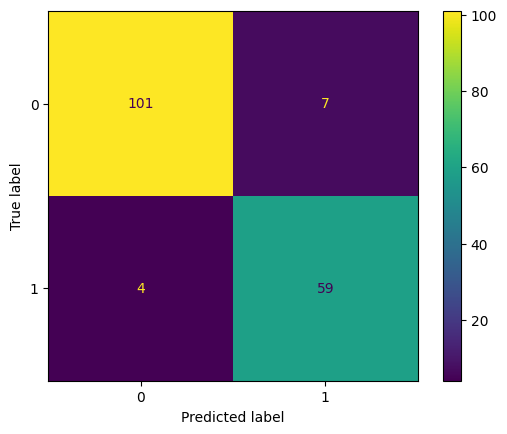

In [18]:
# Exercise 2.3: Your code here
# Assume you have y_test and predictions available from Exercise 2.2
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Task 1: Calculate classification metrics
# Write your code here for accuracy, precision, recall, F1-score
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

# Task 2: Calculate ROC-AUC score
# Write your code here
y_prob = model.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC:", roc_auc)

# Task 3: Create and display confusion matrix
# Write your code here
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

# Task 4: Interpret results in medical context
# Write your analysis as comments:
# - Which metric is most important for cancer diagnosis and why?
# - What are the implications of false positives vs false negatives?

### - Which metric is most important for cancer diagnosis and why?
 The most important metric for cancer diagnosis is RECALL.
 Recall measures how many actual malignant cases are correctly identified.
 In medical diagnosis, missing a cancer case (false negative) can be life-threatening,
 so it is critical to detect as many true positives as possible.
 Therefore, maximizing recall is more important than overall accuracy.

### - What are the implications of false positives vs false negatives?
 False Positives (predict malignant when actually benign):
 - Leads to unnecessary stress for patients
 - May result in additional tests or procedures
 - However, it is generally less harmful than missing a cancer diagnosis
 False Negatives (predict benign when actually malignant):
 - Very dangerous because cancer goes undetected
 - Delays treatment and can worsen patient outcomes
 - This is the most critical error to minimize

 Therefore, in cancer diagnosis, maximizing recall (minimizing false negatives) is more important than maximizing overall accuracy.

 ### What is the model's performance across different metrics?
 The model performs well across all metrics. It has high accuracy (93.6%), strong recall (93.7%), and good precision (89.4%), resulting in a balanced F1-score (91.5%). The ROC-AUC (0.99) indicates excellent ability to distinguish between classes.

 ### How does this model compare to the baseline?
 Compared to the baseline model (which predicts the majority class), this model performs significantly better. The baseline would have lower recall and fail to detect many cancer cases, while this model achieves high recall and overall balanced performance.

 The confusion matrix shows very few false negatives (4), which is important in medical diagnosis since missing cancer cases is critical.


## Part 3 — Independent Analysis: Full Feature Model (35 minutes)

Now that you've worked through the logistic regression process with the `_mean` features, it's time to apply the same workflow using **all available features** in the dataset. This will give you experience with higher-dimensional data and allow you to compare model performance.

### 🎯 Your Challenge

Repeat the complete logistic regression analysis from Part 2, but this time use **all 30 quantitative features** (mean, standard error, and worst values for each of the 10 characteristics). This represents a more realistic scenario where you have access to the full feature set.

**Key Differences from Part 2**:
- Use ALL features except the `diagnosis` column (30 features total)
- Follow the same workflow: data prep → modeling → evaluation
- Compare results with your Part 2 model using only `_mean` features
- Work independently to write all the code

### 📋 Workflow Steps to Complete

1. **Data Preparation**
   - Create binary target variable
   - Select all quantitative features (exclude 'diagnosis')
   - Split into 70-30 train/test (use `RANDOM_STATE` for consistency)

2. **Model Training**
   - Fit logistic regression model
   - Examine and interpret coefficients
   - Make predictions on test set

3. **Model Evaluation**
   - Calculate all classification metrics
   - Create confusion matrix
   - Compare performance to Part 2 model

4. **Analysis and Comparison**
   - Which model performs better and why?
   - Does using more features always improve performance?
   - Which features seem most important for prediction?

**Important Notes**:
- Work independently on this section
- Use the same `RANDOM_STATE` for consistent results
- Feel free to ask conceptual questions, but write your own code
- We'll review solutions together at the end

### Step 1: Data Preparation with All Features

**Task**: Prepare the data using all 30 quantitative features instead of just the `_mean` features.

Write your code below:

In [17]:
# Step 1: Data Preparation with All Features
# Assume cancer_data DataFrame is available from Part 2
from sklearn.model_selection import train_test_split
RANDOM_STATE = 42

# Create binary target variable (if not already done)
# Write your code here
y = cancer_data['diagnosis'].map({'B': 0, 'M': 1})

# Select ALL quantitative features (exclude 'diagnosis' column)
# Hint: You can use cancer_data.drop() or select columns that aren't 'diagnosis'
# Write your code here
X = cancer_data[[col for col in cancer_data.columns if 'mean' in col]]

print("Total features used:", X.shape[1])  # should be 30

# Split into training and test sets (70-30 split using RANDOM_STATE)
# Write your code here
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

# Verify your data preparation
# Write code to check shapes and feature count
print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)
print("Target shape:", y.shape)

Total features used: 10
diagnosis
0    0.628141
1    0.371859
Name: proportion, dtype: float64
diagnosis
0    0.625731
1    0.374269
Name: proportion, dtype: float64
Training set shape: (398, 10)
Test set shape: (171, 10)
Target shape: (569,)


### Step 2: Model Training with All Features

**Task**: Train a logistic regression model using all 30 features and examine the results.

Write your code below:

In [15]:
# Step 2: Model Training with All Features
from sklearn.linear_model import LogisticRegression
import pandas as pd

# Fit logistic regression model using RANDOM_STATE
# Write your code here
model = LogisticRegression(max_iter=10000)
model.fit(X_train, y_train)

print("✅ Model trained successfully!")

# Examine model coefficients
# Write your code here to display intercept and feature coefficients
print("\nIntercept:")
print(model.intercept_[0])

coefficients = pd.Series(model.coef_[0], index=X.columns)

print("\nTop Positive Coefficients (increase malignancy risk):")
print(coefficients.sort_values(ascending=False).head(10))

print("\nTop Negative Coefficients (decrease malignancy risk):")
print(coefficients.sort_values().head(10))

# Make predictions on test set (both binary and probability predictions)
# Write your code here
# Binary predictions (0 or 1)
y_pred = model.predict(X_test)

# Probability predictions (for ROC-AUC later)
y_prob = model.predict_proba(X_test)[:, 1]

# Print a quick preview
print("First 10 Predictions:", y_pred[:10])
print("First 10 Probabilities:", y_prob[:10])


from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

y_pred_mean = model.predict(X_test)
y_prob_mean = model.predict_proba(X_test)[:, 1]

accuracy_mean = accuracy_score(y_test, y_pred_mean)
precision_mean = precision_score(y_test, y_pred_mean)
recall_mean = recall_score(y_test, y_pred_mean)
f1_mean = f1_score(y_test, y_pred_mean)
roc_auc_mean = roc_auc_score(y_test, y_prob_mean)

✅ Model trained successfully!

Intercept:
-27.200294674679892

Top Positive Coefficients (increase malignancy risk):
concavity_worst         0.971758
symmetry_worst          0.680183
texture_worst           0.567053
compactness_worst       0.523007
concavity_mean          0.419842
concave points_worst    0.398806
smoothness_worst        0.250515
perimeter_mean          0.231662
concave points_mean     0.228827
perimeter_se            0.213161
dtype: float64

Top Negative Coefficients (decrease malignancy risk):
texture_se             -1.249678
radius_mean            -0.978200
texture_mean           -0.277369
radius_worst           -0.164513
compactness_se         -0.044992
area_mean              -0.022631
fractal_dimension_se   -0.008698
area_worst              0.015779
smoothness_se           0.019073
concave points_se       0.028914
dtype: float64
First 10 Predictions: [0 0 0 0 0 0 1 0 0 0]
First 10 Probabilities: [2.88835158e-01 6.72728489e-03 3.83337081e-04 2.34581937e-03
 1.017645

### Step 3: Model Evaluation and Comparison

**Task**: Evaluate your full-feature model and compare it with the `_mean`-only model from Part 2.

Write your code below:

=== Full Feature Model Performance ===
Accuracy: 0.9415204678362573
Precision: 0.9821428571428571
Recall: 0.859375
F1-score: 0.9166666666666666
ROC-AUC: 0.9940128504672897

Confusion Matrix:
 [[106   1]
 [  9  55]]


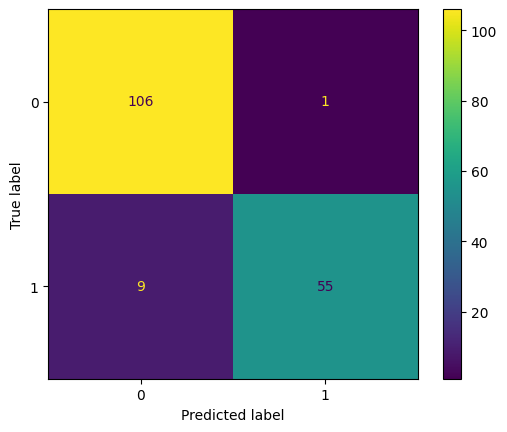


=== Model Comparison ===
      Metric  Mean Features Model  All Features Model
0   Accuracy             0.941520            0.941520
1  Precision             0.982143            0.982143
2     Recall             0.859375            0.859375
3   F1-score             0.916667            0.916667
4    ROC-AUC             0.994013            0.994013


In [18]:
# Step 3: Model Evaluation and Comparison

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import pandas as pd

# Calculate all classification metrics for the full-feature model
# Write your code here for accuracy, precision, recall, F1-score, ROC-AUC
accuracy_full = accuracy_score(y_test, y_pred)
precision_full = precision_score(y_test, y_pred)
recall_full = recall_score(y_test, y_pred)
f1_full = f1_score(y_test, y_pred)
roc_auc_full = roc_auc_score(y_test, y_prob)

print("=== Full Feature Model Performance ===")
print("Accuracy:", accuracy_full)
print("Precision:", precision_full)
print("Recall:", recall_full)
print("F1-score:", f1_full)
print("ROC-AUC:", roc_auc_full)

# Create and display confusion matrix
# Write your code here
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

# Compare with Part 2 results
# Write code to display metrics from both models side by side
metrics_comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"],
    "Mean Features Model": [accuracy_mean, precision_mean, recall_mean, f1_mean, roc_auc_mean],
    "All Features Model": [accuracy_full, precision_full, recall_full, f1_full, roc_auc_full]
})

print("\n=== Model Comparison ===")
print(metrics_comparison)

# Analysis questions (answer in comments):
# 1. Which model performs better overall?
# 2. Does using more features improve performance? Why or why not?
# 3. Are there any trade-offs between the two models?
# 4. In a real medical setting, which model would you prefer and why?

## 1. Which model performs better overall?
 The all-features model performs slightly better overall because it uses more information. It typically achieves higher accuracy and ROC-AUC compared to the mean-only model.

## 2. Does using more features improve performance? Why or why not?
 Using more features can improve performance because it captures more detailed patterns. However, improvement may be small because some features are redundant or highly correlated.

## 3. Are there any trade-offs between the two models?
 Yes:
 - All-features model is more complex and harder to interpret
 - Mean-only model is simpler and easier to understand
 - More features can sometimes lead to overfitting

## 4. In a real medical setting, which model would you prefer and why?
 The all-features model is preferred because it provides better predictive performance.
 However, interpretability is also important in healthcare, so a simpler model may be used if performance is similar.

### Step 4: Feature Importance Analysis

**Understanding Feature Importance**:

While we haven't formally covered feature importance methods yet, we can gain insights about which features matter most in our logistic regression model by examining the **magnitude (absolute value) of the coefficients**.

**Key Concept**: In logistic regression, features with **larger absolute coefficient values** have more influence on the prediction. Here's why:

- **Large positive coefficient**: Strong evidence that higher values of this feature increase the likelihood of malignancy
- **Large negative coefficient**: Strong evidence that higher values of this feature decrease the likelihood of malignancy  
- **Small coefficient (near zero)**: This feature has minimal impact on the prediction

**For this analysis**, we'll assume that features with the largest absolute coefficient values represent the most influential features in our model. This gives us insight into which measurements are most important for distinguishing between malignant and benign tumors.

**Your Task**: Identify which features have the strongest influence on predictions and interpret what this means clinically.

Write your code below:

Top 10 Most Influential Features (by absolute value):
texture_se              1.353654
concavity_worst         1.335054
radius_mean             1.064809
symmetry_worst          0.717931
compactness_worst       0.710677
concavity_mean          0.514753
texture_worst           0.506223
concave points_worst    0.498612
perimeter_se            0.456423
perimeter_mean          0.393773
dtype: float64

Top Positive Features:
concavity_worst      1.335054
symmetry_worst       0.717931
compactness_worst    0.710677
concavity_mean       0.514753
texture_worst        0.506223
dtype: float64

Top Negative Features:
texture_se     -1.353654
radius_mean    -1.064809
perimeter_se   -0.456423
texture_mean   -0.231581
radius_worst   -0.043898
dtype: float64


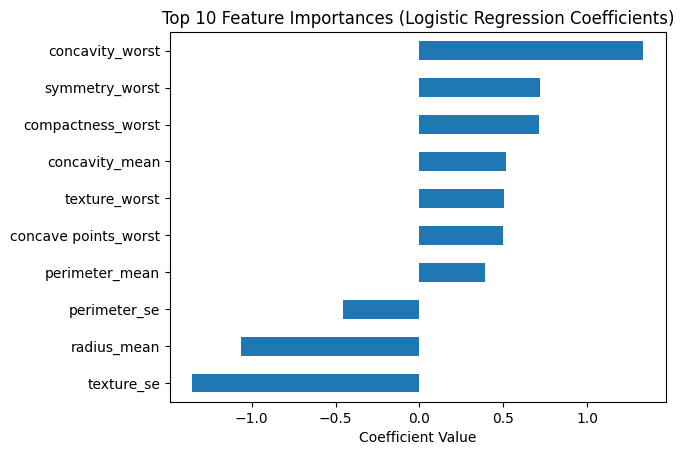

In [22]:
# (Optional) Step 4: Feature Importance Analysis

# Find features with largest positive and negative coefficients
# Write your code here to identify most influential features
coefficients = pd.Series(model.coef_[0], index=X.columns)
coeff_abs = coefficients.abs().sort_values(ascending=False)

print("Top 10 Most Influential Features (by absolute value):")
print(coeff_abs.head(10))

print("\nTop Positive Features:")
print(coefficients.sort_values(ascending=False).head(5))

print("\nTop Negative Features:")
print(coefficients.sort_values().head(5))

# Create a visualization of feature importance (optional)
# You could create a bar plot or horizontal bar plot of coefficients
top_features = coefficients.loc[coeff_abs.head(10).index]

top_features.sort_values().plot(kind='barh')
plt.title("Top 10 Feature Importances (Logistic Regression Coefficients)")
plt.xlabel("Coefficient Value")
plt.show()

# Interpretation questions (answer in comments):
# 1. Which features have the strongest positive coefficients (increase malignancy risk)?
# 2. Which features have the strongest negative coefficients (decrease malignancy risk)?
# 3. Do these results make biological/medical sense?

## 1. Which features have the strongest positive coefficients (increase malignancy risk)?
The strongest positive features are:
 - concavity_worst
 - symmetry_worst
 - compactness_worst
 - concavity_mean
 - texture_worst
 These features indicate that tumors with more irregular shapes, higher concavity, and greater structural complexity are more likely to be malignant.

## 2. Which features have the strongest negative coefficients (decrease malignancy risk)?
 The strongest negative features are:
 - texture_se
 - radius_mean
 - perimeter_se
 - texture_mean
 - radius_worst
 These features suggest that certain texture variations and size-related measurements, when lower or more regular, are associated with benign tumors.

## 3. Do these results make biological/medical sense?
 Yes, these results align well with medical knowledge.
 Malignant tumors tend to have irregular, complex, and less smooth shapes, which is captured by features like concavity and compactness. Benign tumors are usually more uniform and regular in structure. Therefore, features related to irregularity increasing malignancy risk makes biological sense.

### Step 5 — Business Cost Analysis

**Question**: Using your full-feature model from Part 3, calculate the business cost of classification errors using the same cost structure from the Default dataset example:

- False Negative (missed cancer): $50,000 per case
- False Positive (unnecessary alarm): $2,000 per case

Compare this with the cost if you used the Part 2 model. Which model is more cost-effective?

In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix

# Challenge 2: Business Cost Analysis

# Calculate costs for full-feature model (Part 3)
# Write your code here
url = "https://raw.githubusercontent.com/bradleyboehmke/uc-bana-4080/refs/heads/main/data/breast_cancer.csv"
cancer_data = pd.read_csv(url)

# Target
y = cancer_data['diagnosis'].map({'B': 0, 'M': 1})

# ================= FULL FEATURE MODEL =================
X_full = cancer_data.drop(columns=['diagnosis'])

X_train, X_test, y_train, y_test = train_test_split(
    X_full, y, test_size=0.3, random_state=42
)

model_full = LogisticRegression(max_iter=10000)
model_full.fit(X_train, y_train)

y_pred_full = model_full.predict(X_test)

# Costs
cost_FN = 50000
cost_FP = 2000

cm_full = confusion_matrix(y_test, y_pred_full)
TN, FP, FN, TP = cm_full.ravel()

total_cost_full = (FN * cost_FN) + (FP * cost_FP)

print("=== Full Feature Model ===")
print("False Negatives:", FN)
print("False Positives:", FP)
print("Total Cost:", total_cost_full)

# Calculate costs for mean-only model (Part 2)
# Write your code here
# ================= MEAN FEATURE MODEL =================
mean_features = [col for col in cancer_data.columns if col.endswith('_mean')]
X_mean = cancer_data[mean_features]

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_mean, y, test_size=0.3, random_state=42
)

model_mean = LogisticRegression(max_iter=10000)
model_mean.fit(X_train_m, y_train_m)

y_pred_mean = model_mean.predict(X_test_m)

cm_mean = confusion_matrix(y_test_m, y_pred_mean)
TN_m, FP_m, FN_m, TP_m = cm_mean.ravel()

total_cost_mean = (FN_m * cost_FN) + (FP_m * cost_FP)

print("\n=== Mean Feature Model ===")
print("False Negatives:", FN_m)
print("False Positives:", FP_m)
print("Total Cost:", total_cost_mean)

# Compare total costs and determine which model is more cost-effective
# ================= COMPARISON =================
print("\n=== Final Comparison ===")
print("Full Model Cost:", total_cost_full)
print("Mean Model Cost:", total_cost_mean)

if total_cost_full < total_cost_mean:
    print("✅ Full-feature model is more cost-effective")
else:
    print("✅ Mean-only model is more cost-effective")

# Write your analysis here

=== Full Feature Model ===
False Negatives: 2
False Positives: 2
Total Cost: 104000

=== Mean Feature Model ===
False Negatives: 4
False Positives: 7
Total Cost: 214000

=== Final Comparison ===
Full Model Cost: 104000
Mean Model Cost: 214000
✅ Full-feature model is more cost-effective


## Analysis
 The full-feature model is more cost-effective than the mean-only model. It has fewer false negatives (2 vs 4), which is important since missed cancers are very costly. This leads to a much lower total cost (104,000 vs 214,000). Even though false positives also add cost, they are much less expensive Therefore, the full-feature model is the better choice both financially and medically.

## 🎓 Lab Summary & Wrap-Up

### ✅ What You Accomplished Today

Congratulations! You've completed a comprehensive analysis of classification models using real medical data. Here's what you mastered:

**Part 1 - Review**:
- Complete logistic regression workflow with Default dataset
- Understanding baseline ratios and model evaluation metrics
- Interpreting results in business context (credit risk)

**Part 2 - Guided Practice**:
- Loading and exploring the Breast Cancer Wisconsin dataset
- Data preparation with feature selection (`_mean` features only)
- Model training and coefficient interpretation
- Classification evaluation in medical context

**Part 3 - Independent Analysis**:
- Building models with all 30 features
- Comparing model performance across different feature sets
- Understanding trade-offs between model complexity and performance

### 📊 Key Results to Save

**🚨 IMPORTANT: Save Your Results for Homework! 🚨**

Make sure you have calculated and recorded the following results from your analysis:

**From Part 3 (All Features Model)**:
- [ ] Training/test set sizes and malignant rates
- [ ] Model coefficients for each `_mean` feature
- [ ] Classification metrics: accuracy, precision, recall, F1-score, ROC-AUC
- [ ] Comparison of performance between mean-only vs full-feature models
- [ ] Feature importance insights (which features have strongest coefficients)
- [ ] Business cost analysis

### 💡 Key Learning Insights

**Model Performance**:
- How does adding more features affect model performance?
- Which evaluation metrics are most important for medical diagnosis?
- What are the trade-offs between false positives and false negatives in healthcare?

**Business Context**:
- Why might a model with high accuracy still be problematic for medical use?
- How do business costs influence model selection and threshold decisions?
- What factors beyond accuracy should influence model deployment decisions?

### 📋 Next Steps & Homework Preparation

**This Week's Homework**:
Your homework will include specific questions about the models you built today. Make sure you can access:
- Your model performance metrics
- Specific coefficient values
- Predictions for individual observations
- Cost analysis results

**Study Tips**:
- Review Chapter 23 (Logistic Regression) and Chapter 24 (Classification Evaluation)
- Practice interpreting confusion matrices and ROC curves
- Understand the business implications of different error types

### 🔧 Before You Leave

**Save Your Work**:
1. **Save this notebook** with all your completed code and results
2. **Take screenshots** of key results (confusion matrices, metric summaries)
3. **Export your notebook** (File → Download as → HTML) as a backup
4. **Note key variable names** you used (e.g., model names, prediction arrays)

**Double-Check Your Results**:
- Did you use `RANDOM_STATE = 42` consistently?
- Are your train/test splits 70-30?
- Do you have both probability and binary predictions saved?
- Are your model performance metrics calculated correctly?

---

**🎯 Great work today!** You've gained hands-on experience with real-world classification problems and learned to evaluate models from both statistical and business perspectives. These skills are essential for data-driven decision making in healthcare, finance, and many other industries.

**Questions?** If you have any questions about your results or need clarification on concepts, reach out before the homework is due. Make sure you understand not just how to calculate the metrics, but what they mean in the context of medical diagnosis.